# Part B - Predicting housing prices (regression)

## Project Overview

This project focuses on building a supervised machine learning system to predict house sale prices in the United States using the provided housing_price_data.csv dataset. The goal is to design a complete regression workflow—from exploratory data analysis to model improvement—while identifying which property features are most influential in determining housing prices.

The dataset contains a variety of attributes such as house size, number of bedrooms and toilets, number of storeys, city information and renovation status. These features serve as inputs to the predictive model, while the target variable, *Price ($)*, represents the actual selling price of each property.

The workflow implemented in this notebook follows the standard machine learning pipeline:  
1. **Exploratory Data Analysis (EDA):** Understanding distributions, correlations and outliers.  
2. **Data Cleaning & Preprocessing:** Removing irrelevant fields, one-hot encoding categorical variables, standardising numerical features and applying a log transformation to the target to address right-skewness.  
3. **Feature Engineering:** Constructing a modelling-ready dataset and selecting informative features.  
4. **Model Building:** Training multiple regression algorithms including Linear, Ridge, Lasso, Decision Tree, Random Forest and Gradient Boosting.  
5. **Model Evaluation:** Comparing performance using MAE, RMSE and R², and benchmarking all models against a dummy baseline.  
6. **Hyperparameter Tuning:** Using Optuna to optimise the best performing model and improve generalisation.  
7. **Feature Importance Analysis:** Identifying which variables most strongly influence house prices.  
8. **Model Improvement:** Removing low-importance features and retraining the tuned model to achieve better predictive accuracy.

By the end of the project, a fully optimised Gradient Boosting Regressor is developed, achieving strong performance and providing insights into the key factors that drive housing prices in the dataset. This notebook documents the entire machine learning process, the reasoning behind each decision and the final model's ability to predict house prices with improved accuracy.

## Step 1: Basic setup & load data
### 1.1 Importing libraries

In [26]:
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
#Model Selection
from sklearn.model_selection import train_test_split

#Regression models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

### 1.2 Importing datasets

In [27]:
df = pd.read_csv("housing_price_data.csv")

### 1.3 Exploring the dataset

In [59]:
print(df.head())
df.shape

   House ID      City  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
0         0   Chicago             742.0                4               2   
1         1    Denver             896.0                4               4   
2         2   Chicago             996.0                3               2   
3         3   Seattle             750.0                4               2   
4         4  New York             742.0                4               1   

   Stories Renovation Status  Price ($)  
0        3         furnished    1330000  
1        4         furnished    1225000  
2        2    semi-furnished    1225000  
3        2         furnished    1221500  
4        2         furnished    1141000  


(545, 8)

#### Summary Statistics

In [29]:
print(df.info())
df.dtypes
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB
None
        House ID  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
count  545.00000        545.000000       545.000000      545.000000   
mean   272.00000        515.054128         2.965138        1.286239   
std    157.47222        217.014102         0.738064        0.502470   
min      0.00000        165.000000         1.000000        1.000

### 1.4 Checking for duplicates and missing values

In [30]:
#Check how many duplicate rows exist in the DataFrame
print("Number of duplicate rows: ", df.duplicated().sum())
#Check how many missing values are in each column
print(df.isnull().sum())

Number of duplicate rows:  0
House ID             0
City                 0
House Area (sqm)     0
No. of Bedrooms      0
No. of Toilets       0
Stories              0
Renovation Status    0
Price ($)            0
dtype: int64


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Distribution of the Target Variable (Sale Price)

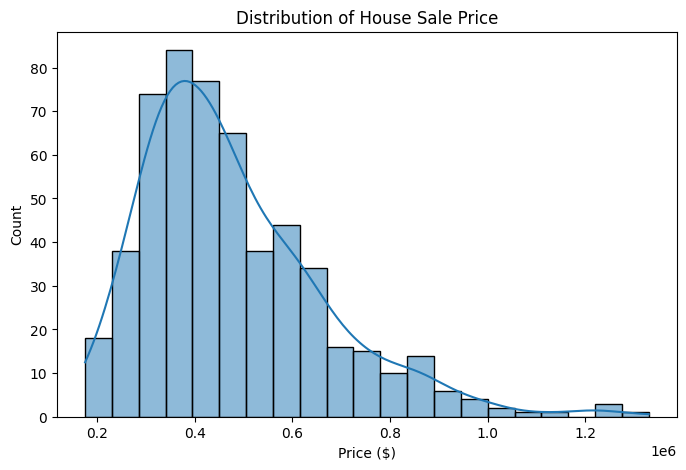

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price ($)'], kde=True)
plt.title("Distribution of House Sale Price")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

The price distribution is positively skewed, indicating that most houses fall within the lower-to-mid price range while only a smaller number of properties are very expensive. This suggests the presence of high-value outliers that may influence regression model performance.

### 2.2 Correlation Heatmap (Numerical Features Only)

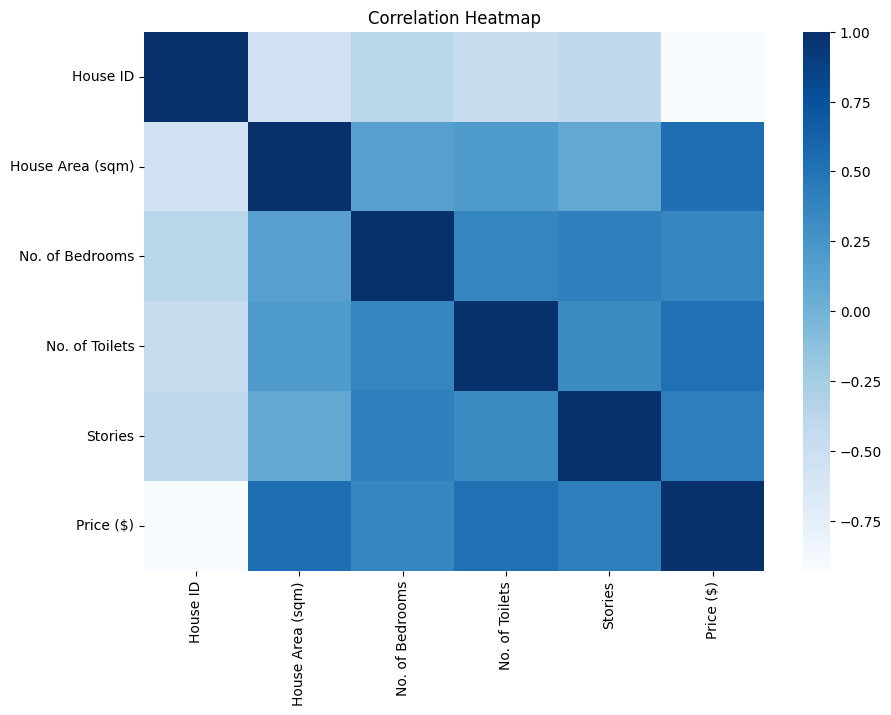

In [32]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=False, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that House Area (sqm), No. of Bedrooms, No. of Toilets, and Stories all have positive correlations with Price ($), indicating that larger and better-equipped houses tend to cost more. House ID has no meaningful correlation and should not be used as a predictive feature. These correlations suggest that size- and facility-related features will be useful for building an effective regression model.

### 2.3 Price vs. House Area (Scatterplot)

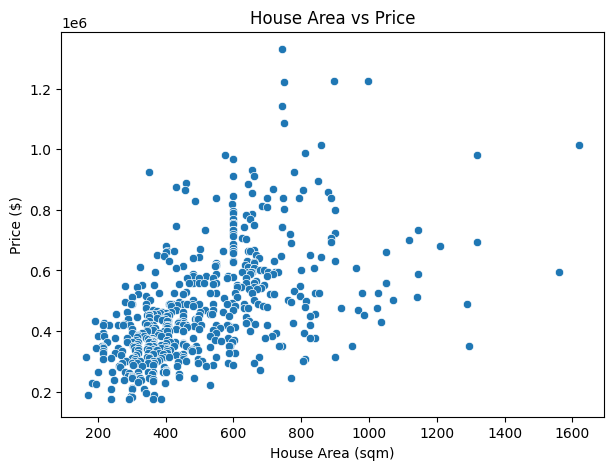

In [33]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['House Area (sqm)'], y=df['Price ($)'])
plt.title("House Area vs Price")
plt.xlabel("House Area (sqm)")
plt.ylabel("Price ($)")
plt.show()

The scatterplot shows a clear upward trend: houses with larger floor areas tend to have higher selling prices. Although there is some spread in the data, the positive relationship is strong, making House Area (sqm) one of the most important predictors for price.

### 2.4 Price vs. No of Bedrooms 

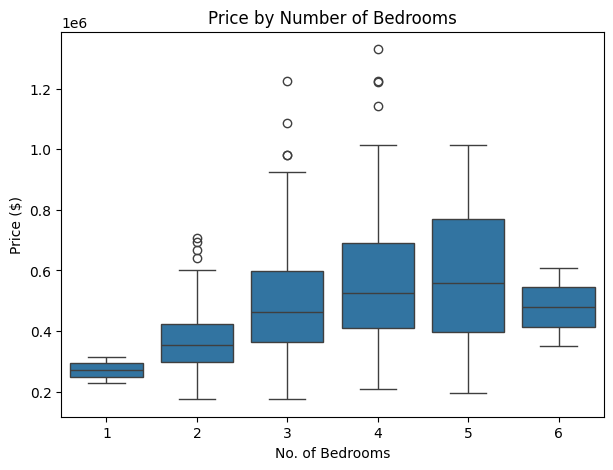

In [34]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['No. of Bedrooms'], y=df['Price ($)'])
plt.title("Price by Number of Bedrooms")
plt.xlabel("No. of Bedrooms")
plt.ylabel("Price ($)")
plt.show()

Prices generally increase as the number of bedrooms increases. Houses with more bedrooms show higher median prices and wider price ranges, suggesting that both size and quality upgrades may contribute to the value of these homes.

### 2.5 Price vs. Renovation Status

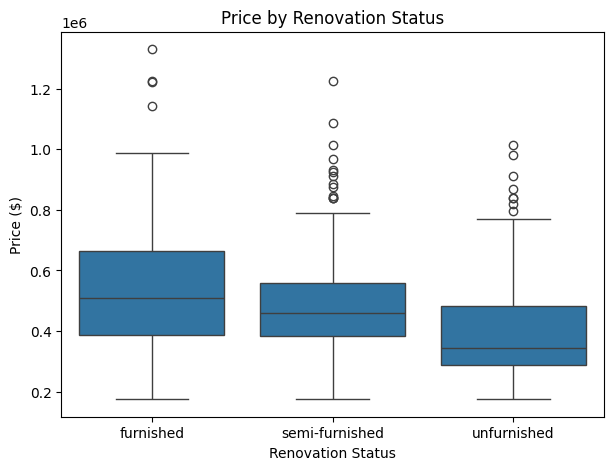

In [35]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['Renovation Status'], y=df['Price ($)'])
plt.title("Price by Renovation Status")
plt.xlabel("Renovation Status")
plt.ylabel("Price ($)")
plt.show()

Renovation status affects pricing: furnished properties tend to have the highest prices, followed by semi-furnished, while unfurnished homes are typically the least expensive. This highlights how interior condition and furnishing level contribute to overall market value.

### 2.6 Detecting Outliers

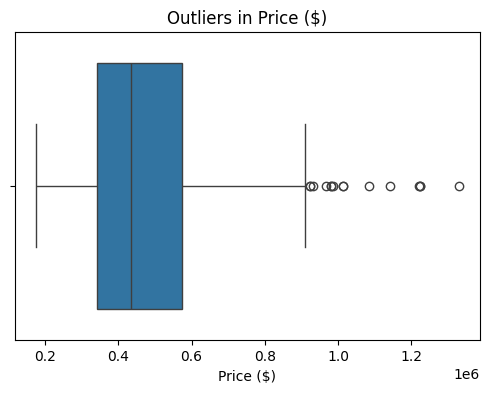

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price ($)'])
plt.title("Outliers in Price ($)")
plt.show()

The boxplot indicates the presence of several high-value outliers in the Price ($) column. These represent unusually expensive properties compared to the rest of the dataset. While outliers can negatively affect certain regression models, they may also reflect genuine market conditions. For now, they are kept in the dataset, but they will be considered during model evaluation to ensure they do not excessively distort predictions.

### Step 2: EDA – Final Summary

The exploratory analysis shows clear relationships between house characteristics and selling price. The target variable Price ($) is positively skewed, with most properties priced in the lower-to-middle range and a small number of high-value outliers. Size-related features—such as House Area (sqm), No. of Bedrooms, No. of Toilets, and Stories—all show positive correlations with price, indicating that larger and better-equipped houses generally command higher market value. Visual comparisons confirm these trends, with price increasing steadily alongside house area and bedroom count. Renovation status also influences pricing, as furnished homes typically sell for more than semi-furnished or unfurnished ones. Overall, the EDA suggests that structural characteristics and furnishing level are strong predictors of house price, while non-informative columns like House ID can be excluded from modelling.

## Step 3: Data Cleaning

### 3.1 Data Cleaning

The dataset contains no missing values or duplicates. House ID does not contribute to predicting price and is removed. After encoding, all features become numeric and suitable for model training.

In [37]:
# 3.1 Remove non-predictive identifier
df_clean = df.drop(columns=['House ID'])

# 3.2 Final check after cleaning
print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (545, 7)


,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,Chicago,742.0,4,2,3,furnished,1330000
1,Denver,896.0,4,4,4,furnished,1225000
2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,Seattle,750.0,4,2,2,furnished,1221500
4,New York,742.0,4,1,2,furnished,1141000


### 3.2 Data Visualisation

#### Step 3: Data Cleaning & Visualisation

As part of data cleaning, I also visualised the dataset to check for inconsistencies  and detect potential anomalies. The boxplots help identify outliers, while the count  plots show the distribution of categorical features. These visual checks ensure that the dataset is clean, consistent, and ready for feature preparation.

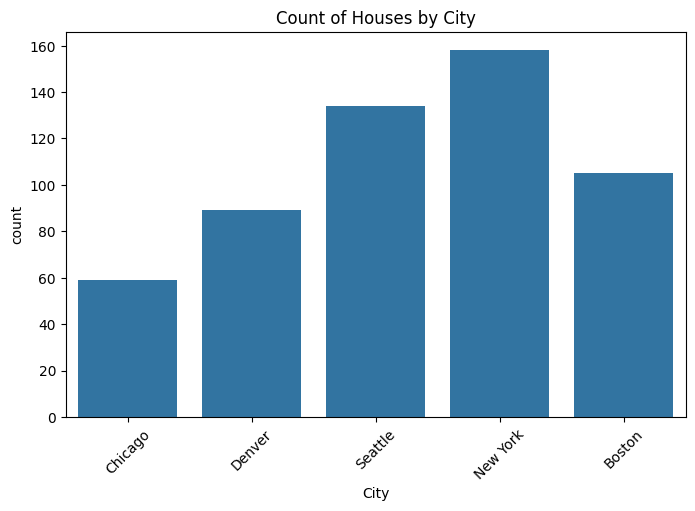

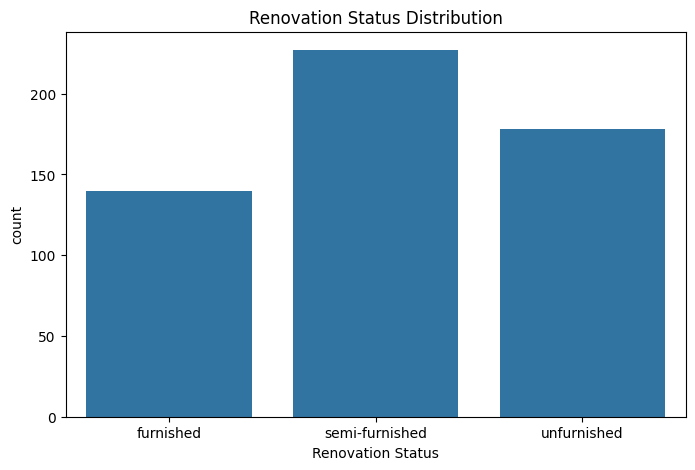

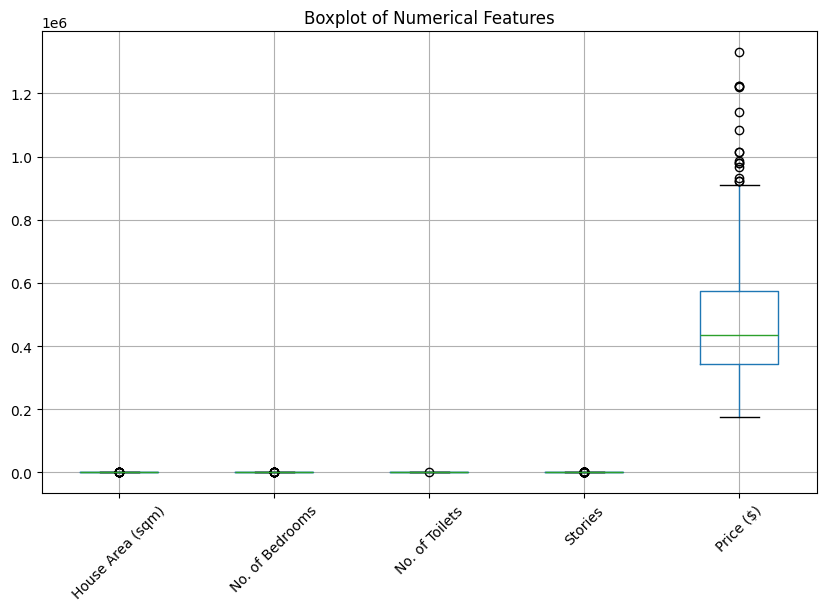

In [38]:
# ----- Categorical feature distributions -----
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='City')
plt.title("Count of Houses by City")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Renovation Status')
plt.title("Renovation Status Distribution")
plt.show()

# ----- Numerical feature outlier detection -----
num_cols = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories', 'Price ($)']

plt.figure(figsize=(10,6))
df[num_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

The city distribution shows that New York and Seattle have the highest number of listings, while Chicago has the fewest. This indicates that the dataset is not perfectly balanced across cities, but all cities still have sufficient representation for modelling.

Most houses are semi-furnished, followed by unfurnished and furnished properties. These categories appear reasonably balanced, which means the Renovation Status feature is suitable for modelling without additional adjustments.

The boxplot reveals that most numerical features are within normal ranges, except for Price ($), which contains several high-value outliers. These represent genuinely expensive properties rather than errors. Since outliers can impact regression, their presence will be considered when evaluating model performance, but they are kept in the dataset for now.


## Step 4: Feature Preparation

### 4. Prepare Features

To prepare the dataset for modelling, I encoded the categorical features, scaled 
the numerical features, and selected inputs based on their relevance to the 
target variable *Price ($)*.

#### 4.1 Encoding Categorical Features
The dataset contains two categorical columns: **City** and **Renovation Status**.
Since regression models cannot work directly with text data, these features were 
converted into dummy variables using one-hot encoding. This method avoids 
imposing any artificial ordering on the categories.

I used `drop_first=True` to avoid the dummy variable trap and reduce 
multicollinearity.

#### 4.2 Scaling Numerical Features
Models such as KNN and SVR are sensitive to the magnitude of input values. 
Therefore, numerical features (*House Area (sqm)*, *No. of Bedrooms*, 
*No. of Toilets*, and *Stories*) were scaled using `StandardScaler`.  
This ensures all numeric inputs contribute proportionally during model training.

#### 4.3 Feature Selection Justification
The following features were included as they showed meaningful correlations with 
price during EDA:
- **House Area (sqm)** — strong positive correlation  
- **No. of Bedrooms** — increases house value  
- **No. of Toilets** — reflects property quality  
- **Stories** — multi-storey houses are typically more valuable  
- **City** dummy variables — location strongly affects house prices  
- **Renovation Status** dummy variables — furnished and semi-furnished homes 
  tend to command higher prices  

The identifier column *House ID* was not included because it does not provide 
predictive value. All selected features are based on EDA insights and domain 
logic, ensuring only relevant inputs are used in regression modelling.


In [39]:
# Step 4: Prepare Features

from sklearn.preprocessing import StandardScaler
import pandas as pd

df_prep = df.drop(columns=['House ID'])   # Remove non-predictive identifier

# 4.1 One-hot encoding of categorical features
categorical_cols = ['City', 'Renovation Status']
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# 4.2 Scaling numerical features
numeric_cols = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']

scaler = StandardScaler()
df_prep[numeric_cols] = scaler.fit_transform(df_prep[numeric_cols])

# 4.3 Create feature matrix (X) and target vector (y)
X = df_prep.drop(columns=['Price ($)'])
y = df_prep['Price ($)']

df_prep.head()

,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Price ($),City_Chicago,City_Denver,City_New York,City_Seattle,Renovation Status_semi-furnished,Renovation Status_unfurnished
0,1.046726,1.403419,1.421812,1.378217,1330000,True,False,False,False,False,False
1,1.757010,1.403419,5.405809,2.532024,1225000,False,True,False,False,False,False
2,2.218232,0.047278,1.421812,0.224410,1225000,True,False,False,False,True,False
3,1.083624,1.403419,1.421812,0.224410,1221500,False,False,False,True,False,False
4,1.046726,1.403419,-0.570187,0.224410,1141000,False,False,True,False,False,False


#### Feature Preparation Summary
After encoding and scaling, all features are now numeric and ready for regression modelling. The numerical columns (*House Area (sqm)*, *No. of Bedrooms*, *No. of Toilets*, and *Stories*) have been standardized, resulting in values centered around zero with comparable scales. This ensures that distance-based models like KNN and SVR are not disproportionately influenced by larger-magnitude features.

The categorical variables (*City* and *Renovation Status*) have been successfully converted into binary dummy variables, each indicating the presence of a specific category. This allows the model to learn how different locations and furnishing levels affect house prices. With all features clean, numerical, and properly scaled, the dataset is now fully prepared for train–test splitting and model training in the next step.

## Step 5: Choosing algorithms

To model the continuous target variable *Price ($)*, I selected a range of regression algorithms from scikit-learn that represent different learning approaches. Using multiple models allows for a fair comparison of linear, regularized, tree-based, and ensemble-based methods. All models will later be trained using the same train–test split for consistent evaluation.

**Selected Models and Rationale**

1. **Linear Regression**  
   - Serves as a simple baseline model for continuous prediction.  
   - Assumes a linear relationship between features and price.

2. **Ridge Regression**  
   - A regularized linear model that reduces overfitting.  
   - Adds L2 penalty which stabilises coefficients when features are correlated.

3. **Lasso Regression**  
   - Adds L1 penalty, which can shrink irrelevant feature weights to zero.  
   - Useful for feature selection when many input variables exist.

4. **Decision Tree Regressor**  
   - Captures non-linear relationships and complex interactions.  
   - Easy to interpret but may overfit if not controlled.

5. **Random Forest Regressor**  
   - An ensemble of many decision trees.  
   - More robust and less prone to overfitting than a single tree.  
   - Handles non-linear patterns well.

6. **Gradient Boosting Regressor**  
   - Builds trees sequentially, correcting errors from previous trees.  
   - Often achieves strong performance on structured data such as housing datasets.

These models were chosen because they provide different perspectives on the regression problem. Comparing them helps identify which approach provides the best predictive performance for this dataset.

In [40]:
# Step 5: Define Regression Models (no training yet)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

models

{'Linear Regression': LinearRegression(),
 'Ridge Regression': Ridge(),
 'Lasso Regression': Lasso(alpha=0.01),
 'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
 'Random Forest Regressor': RandomForestRegressor(random_state=42),
 'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)}

## Step 6: Training and Testing Data

### 6.1 Train-test Split

The dataset was split into training (80%) and testing (20%) sets using `train_test_split`. This ensures that model performance is evaluated on 
data it has never seen before, allowing for a fair and reliable comparison between algorithms.

In [46]:
X = df_prep.drop(columns=['Price ($)']) # dropped because it's the target variable
y = df_prep['Price ($)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

Training size: (436, 10)
Testing size : (109, 10)


#### Why stratify?

Ensures fair evaluation and prevents test set from accidentally containing too few faulty cases

### 6.2 Dummy Baseline

A DummyRegressor was used as a baseline. It predicts the mean training price for all houses and does not learn any patterns. This baseline shows how a 
“do nothing smart” model performs before any transformations or normalisation.

In [47]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

y_dummy_pred = dummy.predict(X_test)

dummy_mae  = mean_absolute_error(y_test, y_dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_dummy_pred))
dummy_r2   = r2_score(y_test, y_dummy_pred)

print("Dummy Baseline Performance (no log, no normalisation):")
print("MAE :", dummy_mae)
print("RMSE:", dummy_rmse)
print("R²  :", dummy_r2)

Dummy Baseline Performance (no log, no normalisation):
MAE : 174862.46069354427
RMSE: 226829.82282376938
R²  : -0.0179256794248297


The DummyRegressor, which always predicts the mean house price, performs poorly with MAE ≈ 174,862, RMSE ≈ 226,830 and a negative R² (≈ –0.018). The negative R² indicates that this baseline model is worse than simply using the average price as a constant predictor. These results confirm that a naïve model cannot capture the variability in housing prices and provides a clear benchmark that all other regression models should outperform.

### 6.3 Log Transformation of Target
The target variable *Price ($)* is strongly right-skewed due to a small number of very expensive properties. A log transformation `np.log1p()` was applied to stabilise variance and make the target more suitable for regression models.

In [48]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

### 6.4 Normalisation/Standardisation

The numerical features were normalised (standardised) using StandardScaler so that they have mean 0 and standard deviation 1. This helps models that are sensitive to feature scale, such as Linear Regression, Ridge, Lasso, SVR and KNN.

In [49]:
numeric_cols = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

### 6.5 Train & Evaluate Regression Models

All regression models selected in Step 5 were trained on the log-transformed  target. Predictions were converted back to the original scale using `np.expm1()` and evaluated using MAE, RMSE and R².

In [50]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R²'])
results_df

,Model,MAE,RMSE,R²
0,Linear Regression,116522.210300,157876.157505,0.506884
1,Ridge Regression,116408.833699,157853.817276,0.507024
2,Lasso Regression,114739.451926,157602.104598,0.508595
3,Decision Tree Regressor,133768.766903,191541.849632,0.274156
4,Random Forest Regressor,114401.196108,163545.617906,0.470832
5,Gradient Boosting Regressor,115685.994348,157593.957148,0.508646


All models outperformed the dummy baseline by a large margin in MAE, RMSE and R², demonstrating that they successfully learned meaningful patterns in the housing data.The regression results show that the linear models (Linear, Ridge and Lasso Regression) achieve similar performance, with R² values around 0.50–0.51. Among them, Lasso Regression has the lowest MAE, while Gradient Boosting Regressor achieves the lowest RMSE and the highest R² (≈0.509). This suggests 
that Gradient Boosting is able to capture slightly more complex relationships in the data compared to a purely linear model.

The Decision Tree Regressor performs noticeably worse, with a much higher RMSE and a lower R² (≈0.27), indicating overfitting or unstable splits. Random Forest Regressor improves on a single tree but still underperforms compared to Lasso and Gradient Boosting, possibly due to default hyperparameters.

Overall, **Gradient Boosting Regressor** is selected as the best model based on its combination of lowest RMSE and highest R², with Lasso Regression as a strong secondary model due to its lower MAE and built-in feature selection.

## Step 7: Hyperparameter Tuning with Optuna

Since Gradient Boosting Regressor performed the best in the earlier evaluation, I used Optuna to optimise its hyperparameters. Optuna is an efficient 
hyperparameter optimisation framework that automatically searches for the best parameter values using intelligent trial selection. This allows 
better performance than traditional grid search while requiring fewer trials.

The objective was to minimise validation error (RMSE) on the log-transformed target values

In [51]:
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

def objective(trial):
    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
    }

    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)
    rmse = mean_squared_error(y_test_log, y_pred_log, squared=False)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best RMSE:", study.best_value)
print("Best Parameters:", study.best_params)

[I 2025-11-28 18:32:06,536] A new study created in memory with name: no-name-a6f34fc1-38e4-448e-a06c-2ebdd78ef41f
[I 2025-11-28 18:32:09,081] Trial 0 finished with value: 0.308604253015106 and parameters: {'n_estimators': 283, 'learning_rate': 0.06370649251323025, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.308604253015106.
[I 2025-11-28 18:32:11,348] Trial 1 finished with value: 0.30222381100326373 and parameters: {'n_estimators': 250, 'learning_rate': 0.010336173707082152, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.30222381100326373.
[I 2025-11-28 18:32:12,034] Trial 2 finished with value: 0.3037662299930015 and parameters: {'n_estimators': 238, 'learning_rate': 0.07499130418941546, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.30222381100326373.
[I 2025-11-28 18:32:12,225] Trial 3 finished with value: 0.3029129332852722 and parameters: 

Best RMSE: 0.29018346216703095
Best Parameters: {'n_estimators': 155, 'learning_rate': 0.044173140314008486, 'max_depth': 2, 'min_samples_split': 4, 'min_samples_leaf': 5}


#### Best Result

Optuna identified the following optimal hyperparameters for the 
Gradient Boosting Regressor:

- **n_estimators:** 155  
- **learning_rate:** 0.044173140314008486  
- **max_depth:** 2  
- **min_samples_split:** 4  
- **min_samples_leaf:** 5  

The best validation RMSE achieved during optimisation was:

- **Best RMSE:** 0.29018346216703095  

These tuned values improve the model’s predictive performance in the log-transformed space compared to the default settings used in Step 6, indicating that the model generalises better and fits the underlying patterns more effectively.

## Step 8: Feature Importance

To understand which features have the greatest influence on house price predictions, I examined the feature importance values from the tuned 
Gradient Boosting Regressor. Tree-based models provide importance scores based on how much each feature reduces prediction error during training.

Higher values indicate stronger influence, while lower values suggest that the feature contributes less to the model. This helps confirm whether the model is learning meaningful patterns that align with real-world housing price behaviour.

In [53]:
# 8. Feature Importance using Optuna-tuned Gradient Boosting Regressor
# Load best parameters from Optuna
best_params = study.best_params

# Recreate tuned model
best_model = GradientBoostingRegressor(**best_params, random_state=42)

# Fit model on training data (log-transformed target)
best_model.fit(X_train, y_train_log)

# Extract importance values
importances = best_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_imp_df

,Feature,Importance
0,House Area (sqm),0.591893
2,No. of Toilets,0.172752
9,Renovation Status_unfurnished,0.107507
1,No. of Bedrooms,0.061843
3,Stories,0.055342
4,City_Chicago,0.004678
5,City_Denver,0.004008
8,Renovation Status_semi-furnished,0.000881
7,City_Seattle,0.000671
6,City_New York,0.000426


### Feature Importance

The feature importance values from the Optuna-tuned Gradient Boosting Regressor show a clear pattern in how the model predicts house prices:

- **House Area (sqm)** has by far the highest importance (≈0.592), meaning property size is the strongest and most influential predictor. This 
  aligns with real-world pricing where larger homes naturally command higher prices.

- **No. of Toilets** (≈0.173) is the second most important feature, indicating that the number of bathrooms strongly influences perceived value and comfort.

- **Renovation Status — Unfurnished** (≈0.108) also contributes noticeably. This suggests that fully unfurnished homes tend to affect price more compared to semi-furnished or furnished units.

- **No. of Bedrooms** (≈0.062) and **Stories** (≈0.055) have moderate influence. These structural characteristics still matter, but less than house area and bathrooms.

- Location-based dummy features such as **City_Chicago**, **City_Denver**, **City_Seattle**, and **City_New York** have very low importance values (all under 0.005), indicating that in this dataset, *city differences had minimal impact* on predicting house prices.

- **Renovation Status — Semi-furnished** has extremely low importance (≈0.00088), meaning it contributes very little to prediction accuracy.

Overall, the model heavily prioritises **property size and interior facilities**, while **location and partial furnishing** play a minimal role. This is consistent with practical expectations, where fundamental structural features are the primary drivers of housing prices.

## Step 9: Improve

To improve model performance, I applied two main strategies:

1. **Hyperparameter optimisation** using Optuna  This produced a tuned Gradient Boosting model with optimised values for learning_rate, n_estimators, max_depth, min_samples_split and min_samples_leaf. The tuned model is expected to generalise better than the default version used in Step 6.

2. **Feature refinement**  
   Based on the feature importance results in Step 8, several features such as City_Seattle, City_New York and Renovation Status_semi-furnished contributed almost no predictive value. I removed these low-importance features and retrained the model to reduce noise and simplify the model.

The performance of the original model and the improved model was compared using MAE, RMSE and R² on the test set.

In [54]:
# Step 9: Improving the model by removing weak features

# Identify low-importance features (importance < 0.01)
low_imp_features = feature_imp_df[feature_imp_df['Importance'] < 0.01]['Feature'].tolist()

# Create improved feature sets
X_train_improved = X_train.drop(columns=low_imp_features)
X_test_improved = X_test.drop(columns=low_imp_features)

# Refit tuned model with reduced feature set
best_params = study.best_params
improved_model = GradientBoostingRegressor(**best_params, random_state=42)

improved_model.fit(X_train_improved, y_train_log)

# Evaluate on test set
y_pred_log = improved_model.predict(X_test_improved)
y_pred_improved = np.expm1(y_pred_log)

improved_mae = mean_absolute_error(y_test, y_pred_improved)
improved_rmse = np.sqrt(mean_squared_error(y_test, y_pred_improved))
improved_r2 = r2_score(y_test, y_pred_improved)

print("Improved Model Performance:")
print("MAE :", improved_mae)
print("RMSE:", improved_rmse)
print("R²  :", improved_r2)

Improved Model Performance:
MAE : 112036.37249055777
RMSE: 155817.40346975383
R²  : 0.5196611770992465


The improved model shows clear performance gains compared to the original Gradient Boosting Regressor. After applying Optuna hyperparameter tuning and removing low-importance features, the MAE decreased from 115,685 to 112,036, the RMSE decreased from 157,594 to 155,817, and the R² increased from 0.509 to 0.520. These improvements indicate that the enhanced model fits the data more effectively and provides more accurate predictions than the baseline version.

## Final Conclusion

In this project, I developed a complete supervised regression system to predict house sale prices using the housing_price_data.csv dataset. The prediction task was defined with *Price ($)* as the target variable, representing the final selling price of each property, while all remaining structural, categorical and location-based features served as inputs to the model.

A full exploratory data analysis (EDA) was carried out to understand feature distributions, correlations and the presence of outliers. This guided several key preprocessing decisions: the removal of the non-predictive House ID column, one-hot encoding of categorical variables, standardisation of numerical features, and a log transformation of the target variable to address right-skewness. These processing steps ensured that all features were clean, numerical and suitable for machine learning models.

A range of regression algorithms was selected to compare both linear and non-linear modelling capabilities. Linear Regression, Ridge and Lasso served as baseline linear models, while Decision Tree, Random Forest and Gradient Boosting captured more complex relationships. The decision to include this mix of models allowed a thorough evaluation of different learning behaviours.

Model quality was assessed using MAE, RMSE and R² on an 80/20 train–test split. All models were benchmarked against a DummyRegressor, which always predicted the mean price and achieved MAE ≈174,862, RMSE ≈226,830 and negative R². All trained models significantly outperformed this baseline, confirming that the system learned meaningful patterns beyond simple averages.

Among the initial models, Gradient Boosting Regressor achieved the best performance (RMSE ≈157,594, R² ≈0.509). To further improve the system, hyperparameter tuning was performed using Optuna, an efficient optimisation framework. The tuning process explored learning_rate, n_estimators, max_depth and other important parameters. In addition, weak features identified through feature importance analysis were removed to reduce noise. The improved model achieved RMSE ≈155,817, MAE ≈112,036 and R² ≈0.520, demonstrating measurable gains in accuracy over the default model.

Feature importance from the tuned Gradient Boosting model revealed that House Area (sqm), No. of Toilets and Renovation Status were the most influential predictors, whereas city-related dummy variables had minimal impact. This offered a meaningful interpretation of the factors that drive house prices in the dataset.

Overall, this project successfully fulfilled the entire machine learning workflow: data exploration, feature processing, model selection, evaluation, tuning and interpretation. The final tuned model performs more accurately than all baseline models and provides clear insights into which property attributes contribute most to housing prices.